In [1]:
import math
import os
import gc
import random

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pprint

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Reading Data

In [3]:
input_data = pd.read_csv("../../data/Mall_Customers.csv")
input_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
input_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


## Data Cleaning

- One-Hot Encoding
- Dropping column 'CustomerID'

In [5]:
input_data = pd.get_dummies(input_data)
input_data = input_data.drop(['CustomerID'], axis = 1)
input_data

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,19,15,39,False,True
1,21,15,81,False,True
2,20,16,6,True,False
3,23,16,77,True,False
4,31,17,40,True,False
...,...,...,...,...,...
195,35,120,79,True,False
196,45,126,28,True,False
197,32,126,74,False,True
198,32,137,18,False,True


## Feature Engineering

Create scaled DataFrame where each variable has a mean of 0 and a standard deviation of 1.

We use scaling so that each variable has equal importance when fitting the k-means algorithm. Otherwise, the variables with the widest ranges would have too much influence.

In [6]:
scaled_data = StandardScaler().fit_transform(input_data)
scaled_data[:10]

array([[-1.42456879, -1.73899919, -0.43480148, -1.12815215,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407, -1.12815215,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298,  0.88640526, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783,  0.88640526, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992,  0.88640526, -0.88640526],
       [-1.20926872, -1.66266033,  1.00159627,  0.88640526, -0.88640526],
       [-0.27630176, -1.62449091, -1.71591298,  0.88640526, -0.88640526],
       [-1.13750203, -1.62449091,  1.70038436,  0.88640526, -0.88640526],
       [ 1.80493225, -1.58632148, -1.83237767, -1.12815215,  1.12815215],
       [-0.6351352 , -1.58632148,  0.84631002,  0.88640526, -0.88640526]])

## Finding The Optimal Number of Clusters

We don’t know beforehand how many clusters is optimal so we must create a plot that displays the number of clusters along with the SSE (sum of squared errors) of the model.

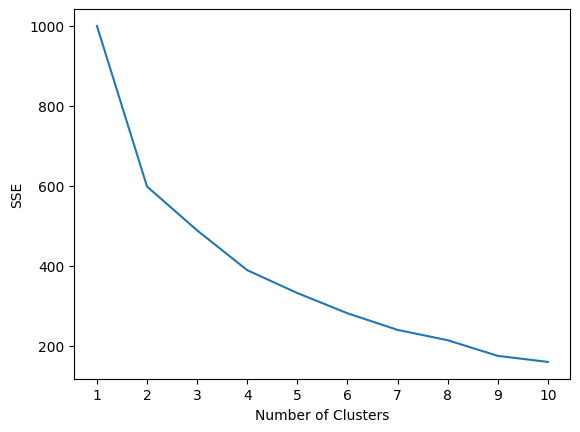

In [7]:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

There is an 'elbow' in the graph where number of clusters is 2. So, we will pick our number of clusters to be 2.

## Performing K-Means Clustering

In [8]:
#instantiate the k-means class, using optimal number of clusters
kmeans = KMeans(init="random", n_clusters=4, n_init=10, random_state=1)

#fit k-means algorithm to data
kmeans.fit(scaled_data)

#view cluster assignments for each observation
kmeans.labels_

array([3, 3, 0, 2, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2, 1, 3, 0, 3, 1, 2, 1, 3,
       0, 3, 0, 3, 0, 3, 0, 2, 1, 2, 1, 3, 0, 2, 0, 2, 0, 2, 0, 3, 1, 2,
       0, 2, 0, 2, 2, 2, 0, 3, 2, 1, 0, 1, 0, 1, 2, 1, 1, 3, 0, 0, 1, 3,
       0, 0, 3, 2, 1, 0, 0, 0, 1, 3, 0, 1, 2, 0, 1, 3, 1, 0, 2, 1, 0, 2,
       2, 0, 0, 3, 1, 0, 2, 3, 0, 2, 1, 3, 2, 0, 1, 3, 1, 2, 0, 1, 1, 1,
       1, 2, 0, 3, 2, 2, 0, 0, 0, 0, 3, 0, 2, 3, 2, 2, 1, 3, 1, 3, 1, 3,
       2, 2, 3, 2, 0, 3, 3, 2, 0, 3, 2, 2, 3, 3, 1, 2, 0, 3, 1, 3, 0, 2,
       0, 2, 1, 2, 1, 2, 0, 2, 3, 2, 1, 2, 1, 2, 0, 3, 1, 3, 1, 3, 0, 2,
       1, 3, 1, 3, 0, 2, 1, 2, 0, 3, 0, 3, 0, 2, 0, 2, 1, 2, 0, 2, 0, 3,
       3, 3], dtype=int32)